# SemEval 2026 Task 6: CLARITY - Political Question Evasion Detection
## Subtask 1: Clarity Classification using Longformer

This notebook trains a classification model for **Subtask 1: Clarity Classification** (3 classes):
- Clear Reply
- Ambivalent
- Clear Non-Reply



## 1. Setup and Installation

In [1]:
# Install required packages
!pip install -q transformers datasets accelerate scikit-learn pandas numpy seaborn matplotlib

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    LongformerTokenizer,
    LongformerForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset as HFDataset
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB


## 2. Configuration

**Important:** These are the exact settings that achieved ~70% accuracy.

In [3]:
# ============================================
# CONFIGURATION - Same as original for 70% accuracy
# ============================================

# Model Configuration
MODEL_NAME = "allenai/longformer-base-4096"

# Sequence Length
MAX_LENGTH = 2048

# Training Configuration
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8  # Effective batch size = 16
LEARNING_RATE = 2e-5
NUM_EPOCHS = 5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

# Data Configuration
DATA_URL = "https://raw.githubusercontent.com/emni8523/nlp_semeval/refs/heads/main/dataset/training_data_processed.csv"
TEST_SIZE = 0.2
RANDOM_STATE = 42

print(f"Model: {MODEL_NAME}")
print(f"Max sequence length: {MAX_LENGTH}")
print(f"Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")

Model: allenai/longformer-base-4096
Max sequence length: 2048
Effective batch size: 16


## 3. Load and Explore Data

In [4]:
# Load data directly from GitHub
df = pd.read_csv(DATA_URL)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (3448, 10)

Columns: ['Unnamed: 0', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'affirmative_questions', 'clarity_label', 'evasion_label']


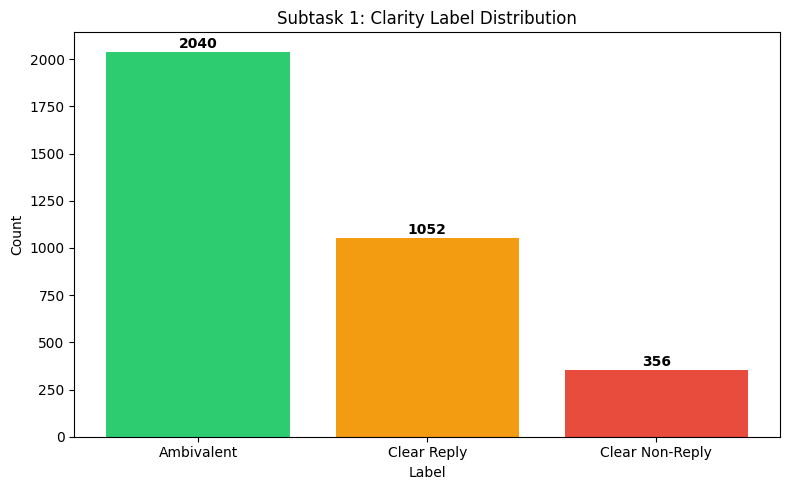


Clarity classes: 3
Class distribution:
clarity_label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64


In [5]:
# Check Clarity label distribution
plt.figure(figsize=(8, 5))
clarity_counts = df['clarity_label'].value_counts()
plt.bar(clarity_counts.index, clarity_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Subtask 1: Clarity Label Distribution', fontsize=12)
plt.xlabel('Label')
plt.ylabel('Count')
for i, v in enumerate(clarity_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClarity classes: {df['clarity_label'].nunique()}")
print(f"Class distribution:\n{df['clarity_label'].value_counts()}")

In [6]:
# Check text lengths
df['combined_text'] = df['interview_question'].fillna('') + ' ' + df['interview_answer'].fillna('')
df['word_count'] = df['combined_text'].apply(lambda x: len(str(x).split()))

print("Combined text word count statistics:")
print(f"  Min: {df['word_count'].min()}")
print(f"  Max: {df['word_count'].max()}")
print(f"  Mean: {df['word_count'].mean():.1f}")
print(f"  Median: {df['word_count'].median():.1f}")
print(f"  95th percentile: {df['word_count'].quantile(0.95):.1f}")
print(f"\n  Samples > 512 words: {(df['word_count'] > 512).sum()} ({(df['word_count'] > 512).mean()*100:.1f}%)")
print(f"  Samples > 1024 words: {(df['word_count'] > 1024).sum()} ({(df['word_count'] > 1024).mean()*100:.1f}%)")

Combined text word count statistics:
  Min: 5
  Max: 2212
  Mean: 355.1
  Median: 257.0
  95th percentile: 1013.0

  Samples > 512 words: 885 (25.7%)
  Samples > 1024 words: 164 (4.8%)


## 4. Text Preparation

In [7]:
def create_input_text(row):
    """Create structured input text from question and answer."""
    parts = []

    # Add question
    if pd.notna(row['question']) and str(row['question']).strip():
        parts.append(f"[QUESTION] {row['question']}")
    elif pd.notna(row['interview_question']) and str(row['interview_question']).strip():
        parts.append(f"[QUESTION] {row['interview_question']}")

    # Add answer
    if pd.notna(row['interview_answer']) and str(row['interview_answer']).strip():
        parts.append(f"[ANSWER] {row['interview_answer']}")

    # Add GPT summary if available
    if 'gpt3.5_summary' in row and pd.notna(row['gpt3.5_summary']) and str(row['gpt3.5_summary']).strip():
        parts.append(f"[SUMMARY] {row['gpt3.5_summary']}")

    # Add GPT analysis if available
    if 'gpt3.5_prediction' in row and pd.notna(row['gpt3.5_prediction']) and str(row['gpt3.5_prediction']).strip():
        parts.append(f"[ANALYSIS] {row['gpt3.5_prediction']}")

    return ' '.join(parts)

# Create input text
df['input_text'] = df.apply(create_input_text, axis=1)

print("Sample input text:")
print(df['input_text'].iloc[0][:500] + "...")

Sample input text:
[QUESTION] How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks? [ANSWER] Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese G...


In [8]:
# Create label mappings for Clarity
clarity_labels = sorted(df['clarity_label'].unique())
clarity_label2id = {label: idx for idx, label in enumerate(clarity_labels)}
clarity_id2label = {idx: label for label, idx in clarity_label2id.items()}

print(f"Clarity labels: {clarity_labels}")
print(f"Label to ID mapping: {clarity_label2id}")

# Add label IDs to dataframe
df['clarity_label_id'] = df['clarity_label'].map(clarity_label2id)

Clarity labels: ['Ambivalent', 'Clear Non-Reply', 'Clear Reply']
Label to ID mapping: {'Ambivalent': 0, 'Clear Non-Reply': 1, 'Clear Reply': 2}


In [9]:
# Split data
train_data, val_data = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['clarity_label_id']
)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"\nTraining clarity distribution:")
print(train_data['clarity_label'].value_counts())

Training samples: 2758
Validation samples: 690

Training clarity distribution:
clarity_label
Ambivalent         1632
Clear Reply         841
Clear Non-Reply     285
Name: count, dtype: int64


## 5. Tokenization

In [10]:
# Load tokenizer
tokenizer = LongformerTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Tokenizer loaded: allenai/longformer-base-4096
Vocab size: 50265


In [11]:
# Convert to Hugging Face Datasets
train_dataset = HFDataset.from_pandas(
    train_data[['input_text', 'clarity_label_id']].rename(columns={'clarity_label_id': 'labels'}).reset_index(drop=True)
)
val_dataset = HFDataset.from_pandas(
    val_data[['input_text', 'clarity_label_id']].rename(columns={'clarity_label_id': 'labels'}).reset_index(drop=True)
)

print("Datasets created!")

Datasets created!


In [12]:
# Tokenize datasets
def tokenize_function(examples):
    """Tokenize with Longformer settings."""
    tokenized = tokenizer(
        examples['input_text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None
    )

    # Longformer requires global attention mask
    # Set global attention on [CLS] token (first token)
    global_attention_mask = [[1] + [0] * (MAX_LENGTH - 1) for _ in range(len(examples['input_text']))]
    tokenized['global_attention_mask'] = global_attention_mask

    return tokenized

print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['input_text'])
val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=['input_text'])
print("Tokenization complete!")

Tokenizing datasets...


Map:   0%|          | 0/2758 [00:00<?, ? examples/s]

Map:   0%|          | 0/690 [00:00<?, ? examples/s]

Tokenization complete!


In [13]:
# Set format for PyTorch
columns_to_keep = ['input_ids', 'attention_mask', 'global_attention_mask', 'labels']

train_dataset.set_format(type='torch', columns=columns_to_keep)
val_dataset.set_format(type='torch', columns=columns_to_keep)

print("Dataset format set to PyTorch tensors!")
print(f"\nTrain dataset features: {train_dataset.column_names}")
print(f"Sample input_ids shape: {train_dataset[0]['input_ids'].shape}")

Dataset format set to PyTorch tensors!

Train dataset features: ['labels', 'input_ids', 'attention_mask', 'global_attention_mask']
Sample input_ids shape: torch.Size([2048])


## 6. Compute Class Weights

In [14]:
# Compute class weights for imbalanced data
clarity_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(list(range(len(clarity_labels)))),
    y=train_data['clarity_label_id'].values
)
clarity_weights = torch.tensor(clarity_weights, dtype=torch.float32)
print(f"Clarity class weights: {clarity_weights}")

Clarity class weights: tensor([0.5633, 3.2257, 1.0931])


## 7. Model Setup

In [15]:
# Custom Trainer with class weights
class WeightedTrainer(Trainer):
    """Custom Trainer that uses class weights for imbalanced data."""

    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fct = nn.CrossEntropyLoss()

        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("WeightedTrainer class defined!")

WeightedTrainer class defined!


In [16]:
# Define metrics computation
def compute_metrics(eval_pred):
    """Compute metrics for evaluation."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

print("Metrics function defined!")

Metrics function defined!


In [17]:
# Load model for Clarity Classification
model = LongformerForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(clarity_labels),
    id2label=clarity_id2label,
    label2id=clarity_label2id
)

print(f"Model loaded for Clarity Classification")
print(f"Number of labels: {len(clarity_labels)}")
print(f"Labels: {clarity_labels}")
print(f"Model parameters: {model.num_parameters():,}")

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at allenai/longformer-base-4096 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded for Clarity Classification
Number of labels: 3
Labels: ['Ambivalent', 'Clear Non-Reply', 'Clear Reply']
Model parameters: 148,661,763


In [18]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./clarity_model_longformer',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    learning_rate=LEARNING_RATE,
    logging_dir='./logs_clarity',
    logging_steps=25,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=RANDOM_STATE,
    dataloader_num_workers=2,
    remove_unused_columns=False,  # Important for global_attention_mask
)

print("Training arguments configured!")

Training arguments configured!


In [19]:
# Create Trainer
trainer = WeightedTrainer(
    class_weights=clarity_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Trainer created!")

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

Trainer created!


## 8. Training

In [20]:
# Train the model
print("="*60)
print("TRAINING SUBTASK 1: CLARITY CLASSIFICATION")
print("="*60)

trainer.train()

TRAINING SUBTASK 1: CLARITY CLASSIFICATION


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.759200,0.766917,0.669565,0.608964,0.669702
2,0.736600,0.814600,0.695652,0.525374,0.670978
3,0.669800,0.695087,0.713043,0.645342,0.713212
4,0.576400,0.718446,0.721739,0.644656,0.718789
5,0.546300,0.707471,0.728986,0.654070,0.724722


TrainOutput(global_step=865, training_loss=0.6927099635835328, metrics={'train_runtime': 6083.2932, 'train_samples_per_second': 2.267, 'train_steps_per_second': 0.142, 'total_flos': 1.811609775747072e+16, 'train_loss': 0.6927099635835328, 'epoch': 5.0})

## 9. Evaluation

In [21]:
# Evaluate model
print("\nEvaluating Clarity Model...")
results = trainer.evaluate()
print(f"\nClarity Model Results:")
for key, value in results.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")


Evaluating Clarity Model...



Clarity Model Results:
  eval_loss: 0.7075
  eval_accuracy: 0.7290
  eval_f1_macro: 0.6541
  eval_f1_weighted: 0.7247
  eval_runtime: 126.1583
  eval_samples_per_second: 5.4690
  eval_steps_per_second: 1.3710
  epoch: 5.0000



Clarity Classification Report:
                 precision    recall  f1-score   support

     Ambivalent       0.80      0.73      0.76       408
Clear Non-Reply       0.59      0.38      0.46        71
    Clear Reply       0.66      0.84      0.74       211

       accuracy                           0.73       690
      macro avg       0.68      0.65      0.65       690
   weighted avg       0.73      0.73      0.72       690



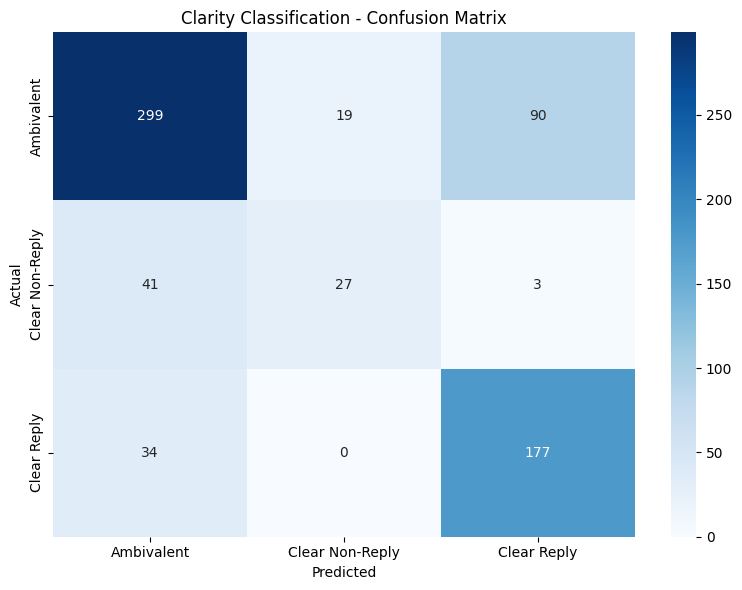

In [22]:
# Detailed classification report
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

print("\nClarity Classification Report:")
print(classification_report(
    labels,
    preds,
    target_names=clarity_labels
))

# Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clarity_labels, yticklabels=clarity_labels)
plt.title('Clarity Classification - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [23]:
# Save the model
trainer.save_model('./clarity_model_longformer_final')
tokenizer.save_pretrained('./clarity_model_longformer_final')
print("Model saved to ./clarity_model_longformer_final")

Model saved to ./clarity_model_longformer_final


## 10. Inference Example

In [24]:
# Load model for inference
from transformers import pipeline

# Load Clarity classifier
clarity_classifier = pipeline(
    'text-classification',
    model='./clarity_model_longformer_final',
    tokenizer='./clarity_model_longformer_final',
    device=0 if torch.cuda.is_available() else -1,
    max_length=MAX_LENGTH,
    truncation=True
)

print("Model loaded for inference!")

Device set to use cuda:0


Model loaded for inference!


In [25]:
# Inference function
def predict_clarity(question, answer, summary="", analysis=""):
    """Make prediction for clarity classification."""
    # Create structured input text
    parts = []
    if question:
        parts.append(f"[QUESTION] {question}")
    if answer:
        parts.append(f"[ANSWER] {answer}")
    if summary:
        parts.append(f"[SUMMARY] {summary}")
    if analysis:
        parts.append(f"[ANALYSIS] {analysis}")

    input_text = ' '.join(parts)

    # Get prediction
    result = clarity_classifier(input_text)[0]

    return {
        'label': result['label'],
        'confidence': result['score']
    }

print("Inference function defined!")

Inference function defined!


In [26]:
# Test with example
test_question = "Do you support the new healthcare policy?"
test_answer = "Healthcare is an important issue that affects many Americans. We need to consider all aspects carefully."

result = predict_clarity(test_question, test_answer)
print(f"\nTest Prediction:")
print(f"  Question: {test_question}")
print(f"  Answer: {test_answer}")
print(f"  Clarity Label: {result['label']}")
print(f"  Confidence: {result['confidence']:.4f}")

Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512



Test Prediction:
  Question: Do you support the new healthcare policy?
  Answer: Healthcare is an important issue that affects many Americans. We need to consider all aspects carefully.
  Clarity Label: Clear Non-Reply
  Confidence: 0.5635


## Summary

This notebook trained a Longformer model for **Subtask 1: Clarity Classification** with the following configuration:

| Parameter | Value |
|-----------|-------|
| Model | allenai/longformer-base-4096 |
| Max Length | 2048 |
| Batch Size | 2 (effective: 16) |
| Learning Rate | 2e-5 |
| Epochs | 5 |
| Warmup Ratio | 0.1 |
| Weight Decay | 0.01 |

